# EXPERIMENT NO. 4
# PRINCIPAL COMPONENT ANALYSIS (PCA)
# Dataset: Iris.csv


# STEP 1: IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score


# STEP 2: LOAD DATASET


In [3]:
df = pd.read_csv(r"C:\Users\hp\Downloads\Iris.csv")

print("========== ORIGINAL DATASET ==========")
print(df.head())


========== ORIGINAL DATASET ==========
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


# STEP 3: DATASET INFORMATION


In [4]:
print("\n========== DATASET INFORMATION ==========")

print("\nShape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())


========== DATASET INFORMATION ==========

Shape:
(150, 6)

Columns:
Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

Missing Values:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Statistical Summary:
               Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
count  150.000000     150.000000    150.000000     150.000000    150.000000
mean    75.500000       5.843333      3.054000       3.758667      1.198667
std     43.445368       0.828066      0.433594       1.764420      0.763161
min      1.000000       4.300000      2.000000       1.000000      0.100000
25%     38.250000       5.100000      2.800000       1.600000      0.300000
50%     75.500000       5.800000      3.000000       4.350000      1.300000
75%    112.750000       6.400000      3.300000       5.100000      1.800000
max    150.000000       7.900000    

# STEP 4: REMOVE DUPLICATES


In [6]:
print("\nDuplicate rows:", df.duplicated().sum())

df = df.drop_duplicates()

print("Shape after removing duplicates:")
print(df.shape)


# STEP 5: SEPARATE FEATURES AND TARGET

X = df[
    [
        "SepalLengthCm",
        "SepalWidthCm",
        "PetalLengthCm",
        "PetalWidthCm"
    ]
]

y = df["Species"]

print("\n========== INPUT FEATURES ==========")
print(X.head())

print("\n========== TARGET ==========")
print(y.head())


Duplicate rows: 0
Shape after removing duplicates:
(150, 6)

========== INPUT FEATURES ==========
   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0            5.1           3.5            1.4           0.2
1            4.9           3.0            1.4           0.2
2            4.7           3.2            1.3           0.2
3            4.6           3.1            1.5           0.2
4            5.0           3.6            1.4           0.2

========== TARGET ==========
0    Iris-setosa
1    Iris-setosa
2    Iris-setosa
3    Iris-setosa
4    Iris-setosa
Name: Species, dtype: object


# STEP 6: STANDARDIZE THE FEATURES


In [7]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("\n========== STANDARDIZED DATA ==========")

print(
    pd.DataFrame(
        X_scaled,
        columns=X.columns
    ).head()
)


========== STANDARDIZED DATA ==========
   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0      -0.900681      1.032057      -1.341272     -1.312977
1      -1.143017     -0.124958      -1.341272     -1.312977
2      -1.385353      0.337848      -1.398138     -1.312977
3      -1.506521      0.106445      -1.284407     -1.312977
4      -1.021849      1.263460      -1.341272     -1.312977


# STEP 7: APPLY PCA


In [8]:
# Original dimensions = 4
# Reduced dimensions = 2

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

print("\n========== PCA TRANSFORMED DATA ==========")

print(pca_df.head())




========== PCA TRANSFORMED DATA ==========
        PC1       PC2
0 -2.264542  0.505704
1 -2.086426 -0.655405
2 -2.367950 -0.318477
3 -2.304197 -0.575368
4 -2.388777  0.674767


# STEP 8: EXPLAINED VARIANCE


print("\n========== EXPLAINED VARIANCE ==========")

pc1_variance = pca.explained_variance_ratio_[0]

pc2_variance = pca.explained_variance_ratio_[1]

total_variance = (
    pc1_variance +
    pc2_variance
)

print(
    "PC1 variance:",
    pc1_variance * 100,
    "%"
)

print(
    "PC2 variance:",
    pc2_variance * 100,
    "%"
)

print(
    "Total variance retained:",
    total_variance * 100,
    "%"
)

# STEP 9: EXPLAINED VARIANCE OF ALL COMPONENTS


In [11]:
pca_all = PCA()

pca_all.fit(X_scaled)

explained_variance = (
    pca_all.explained_variance_ratio_
)

print("\n========== VARIANCE OF ALL COMPONENTS ==========")

for i, value in enumerate(explained_variance):

    print(
        "PC",
        i + 1,
        ":",
        round(value * 100, 2),
        "%"
    )


========== VARIANCE OF ALL COMPONENTS ==========
PC 1 : 72.77 %
PC 2 : 23.03 %
PC 3 : 3.68 %
PC 4 : 0.52 %


# STEP 10: CUMULATIVE VARIANCE


In [12]:
cumulative_variance = np.cumsum(
    explained_variance
)

print("\n========== CUMULATIVE VARIANCE ==========")

for i, value in enumerate(cumulative_variance):

    print(
        "PC",
        i + 1,
        ":",
        round(value * 100, 2),
        "%"
    )



========== CUMULATIVE VARIANCE ==========
PC 1 : 72.77 %
PC 2 : 95.8 %
PC 3 : 99.48 %
PC 4 : 100.0 %


# STEP 11: CUMULATIVE VARIANCE GRAPH


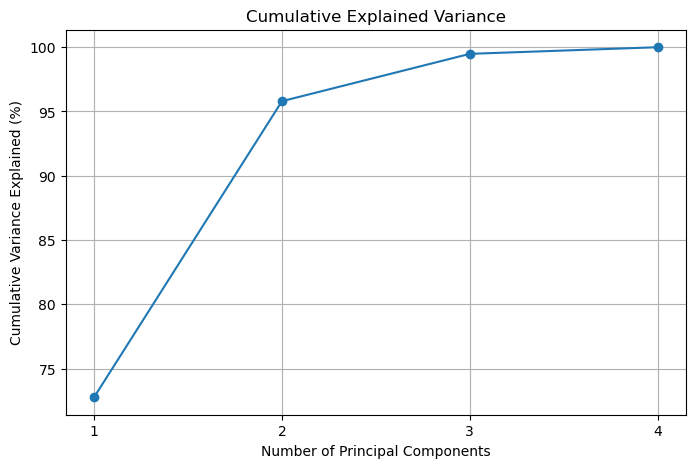

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 5),
    cumulative_variance * 100,
    marker="o"
)

plt.xlabel("Number of Principal Components")

plt.ylabel("Cumulative Variance Explained (%)")

plt.title("Cumulative Explained Variance")

plt.xticks([1, 2, 3, 4])

plt.grid()

plt.show()

# STEP 12: BEFORE PCA VISUALIZATION


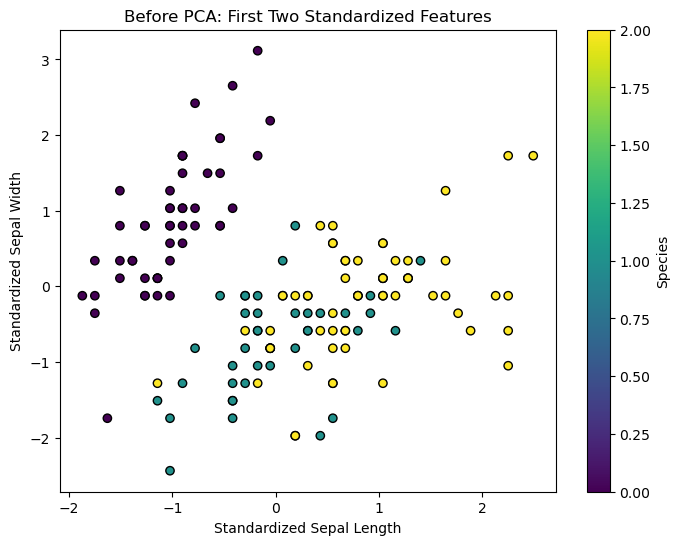

In [14]:
species_codes = pd.factorize(y)[0]

plt.figure(figsize=(8, 6))

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=species_codes,
    cmap="viridis",
    edgecolor="k"
)

plt.xlabel("Standardized Sepal Length")

plt.ylabel("Standardized Sepal Width")

plt.title(
    "Before PCA: First Two Standardized Features"
)

plt.colorbar(
    label="Species"
)

plt.show()

# STEP 13: AFTER PCA VISUALIZATION


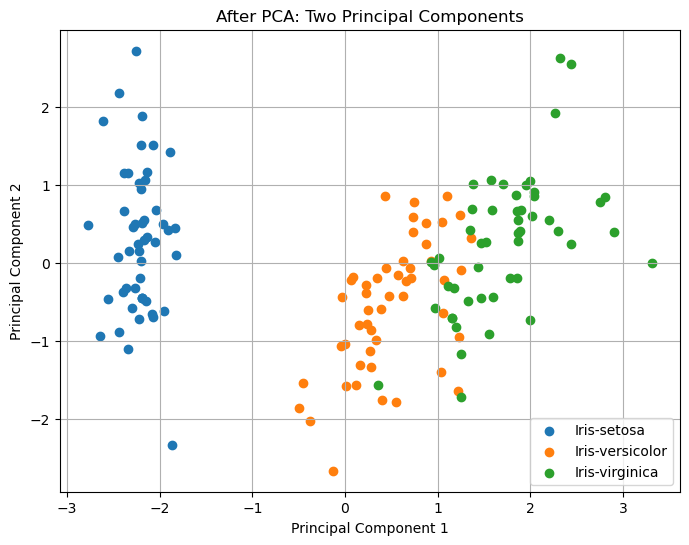

In [16]:
plt.figure(figsize=(8, 6))

for species in y.unique():

    indices = y == species

    plt.scatter(
        X_pca[indices, 0],
        X_pca[indices, 1],
        label=species
    )

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.title(
    "After PCA: Two Principal Components"
)

plt.legend()

plt.grid()

plt.show()



# STEP 14: SPLIT PCA DATA


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X_pca,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("\n========== DATA SPLIT ==========")

print("Training samples:", len(X_train))

print("Testing samples:", len(X_test))


========== DATA SPLIT ==========
Training samples: 105
Testing samples: 45


# STEP 15: LOGISTIC REGRESSION


In [18]:

model = LogisticRegression()

model.fit(
    X_train,
    y_train
)

y_pred = model.predict(X_test)



# STEP 16: CONFUSION MATRIX


In [19]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print("\n========== CONFUSION MATRIX ==========")

print(cm)



========== CONFUSION MATRIX ==========
[[15  0  0]
 [ 0 14  1]
 [ 0  4 11]]


# STEP 17: ACCURACY


In [23]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\nAccuracy:", accuracy)

print(
    "Accuracy percentage:",
    accuracy * 100,
    "%"
)


Accuracy: 0.8888888888888888
Accuracy percentage: 88.88888888888889 %


# STEP 18: CONFUSION MATRIX GRAPH


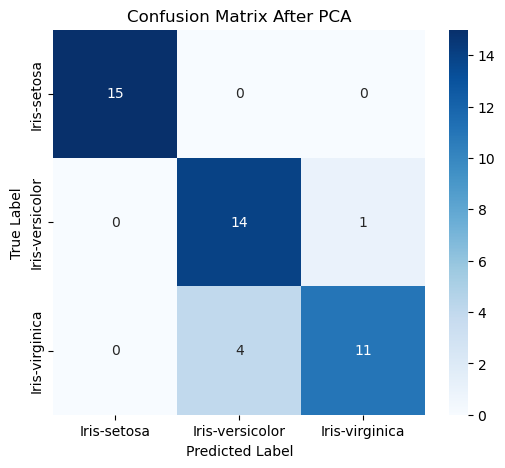

In [24]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=y.unique(),
    yticklabels=y.unique()
)

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.title("Confusion Matrix After PCA")

plt.show()

# STEP 19: FINAL RESULT


In [25]:
print("\n==========================================")
print("              PCA RESULT")
print("==========================================")

print("Original dimensions: 4")

print("Reduced dimensions: 2")

print(
    "PC1 variance:",
    round(pc1_variance * 100, 2),
    "%"
)

print(
    "PC2 variance:",
    round(pc2_variance * 100, 2),
    "%"
)

print(
    "Variance retained:",
    round(total_variance * 100, 2),
    "%"
)

print(
    "Classification accuracy:",
    round(accuracy * 100, 2),
    "%"
)

print("\nPCA practical completed successfully.")


              PCA RESULT
Original dimensions: 4
Reduced dimensions: 2
PC1 variance: 72.77 %
PC2 variance: 23.03 %
Variance retained: 95.8 %
Classification accuracy: 88.89 %

PCA practical completed successfully.
